In [15]:
# Cell 1: Import required libraries
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import glob

%matplotlib inline

In [19]:
# Cell 2: Find the first HDF file and load 1-day / 3-day flood datasets
hdf_dir = '/home/greens/Projects/Flood_Forecasting/Dataset/'
hdf_files = sorted(glob.glob(hdf_dir + '/*.hdf'))
third_file = hdf_files[2]
print(f'Opening: {third_file}')

f = SD(third_file, SDC.READ)
flood_1day = f.select('Flood_1Day_250m').get()
flood_3day = f.select('Flood_3Day_250m').get()
f.end()

# Mask fill values (255 -> NaN) for cleaner plots
flood_1day = flood_1day.astype(np.float32)
flood_3day = flood_3day.astype(np.float32)
flood_1day[flood_1day == 255] = np.nan
flood_3day[flood_3day == 255] = np.nan

Opening: /home/greens/Projects/Flood_Forecasting/Dataset/MCDWD_L3.A2004213.h26v06.061.2025270185011.hdf


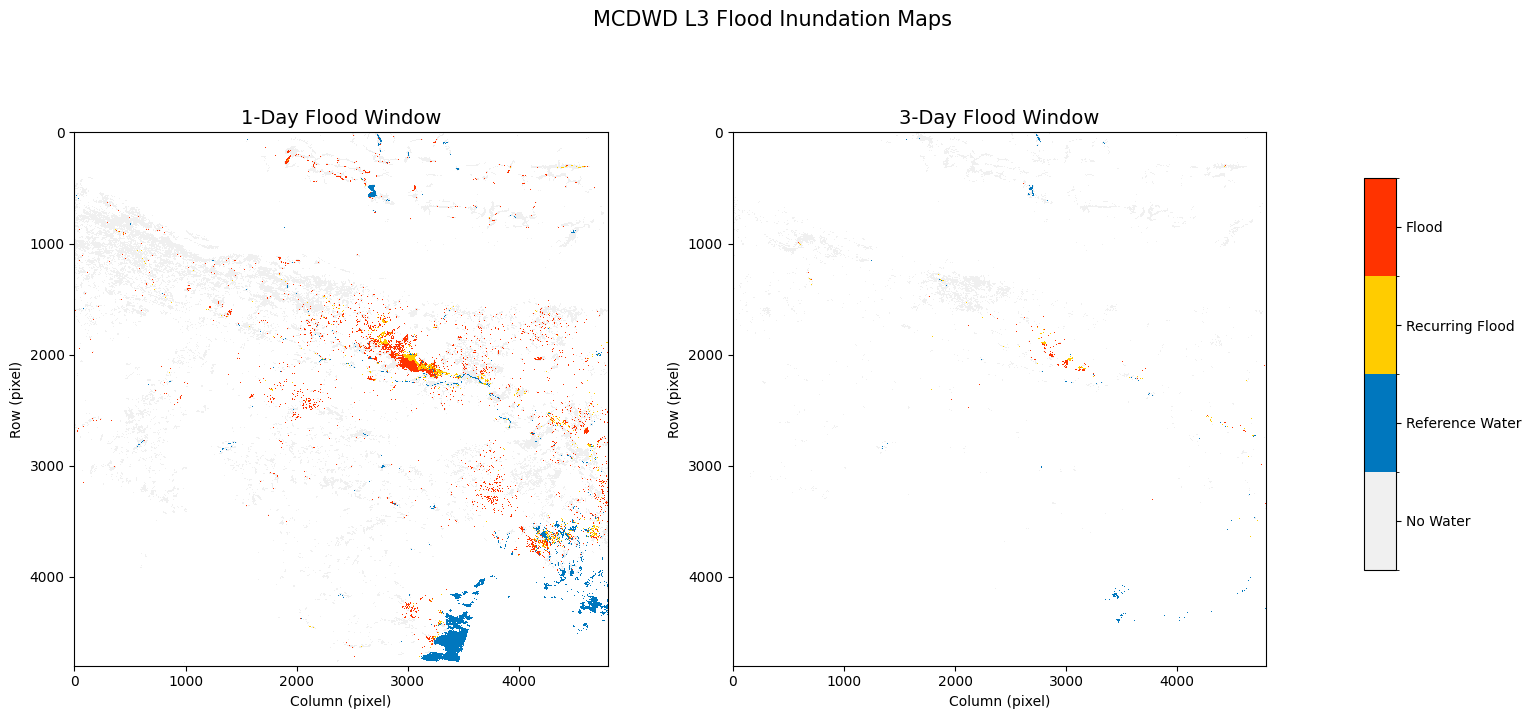

In [ ]:
# Cell 3: Display 1-day and 3-day flood maps side by side
# Classification: 0=No water, 1=Reference water, 2=Recurring flood, 3=Flood, 255=No data
cmap = ListedColormap(['#f0f0f0', '#0077be', '#ffcc00', '#ff3300'])
norm = BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title in zip(axes, [flood_1day, flood_3day],
                           ['1-Day Flood Window', '3-Day Flood Window']):
    im = ax.imshow(data, cmap=cmap, norm=norm, interpolation='none')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Column (pixel)')
    ax.set_ylabel('Row (pixel)')

plt.suptitle('MCDWD L3 Flood Inundation Maps', fontsize=15, y=1.02)
plt.tight_layout(rect=[0, 0, 0.84, 0.95])
cbar_ax = fig.add_axes([0.87, 0.22, 0.02, 0.56])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0.5, 1.5, 2.5, 3.5])
cbar.ax.set_yticklabels(['No Water', 'Reference Water',
                          'Recurring Flood', 'Flood'])
plt.show()

Original shape: (4800, 4800) (23,040,000 pixels)
Coarse shape (1 km): (1200, 1200) (1,440,000 pixels)
Coarse known: 216,703
Coarse unknown: 1,223,297

nearest: NaN filled -> No Water:931711, Ref Water:94811, Recur Flood:12745, Flood:184030
linear: NaN filled -> No Water:753774, Ref Water:175045, Recur Flood:105285, Flood:89308


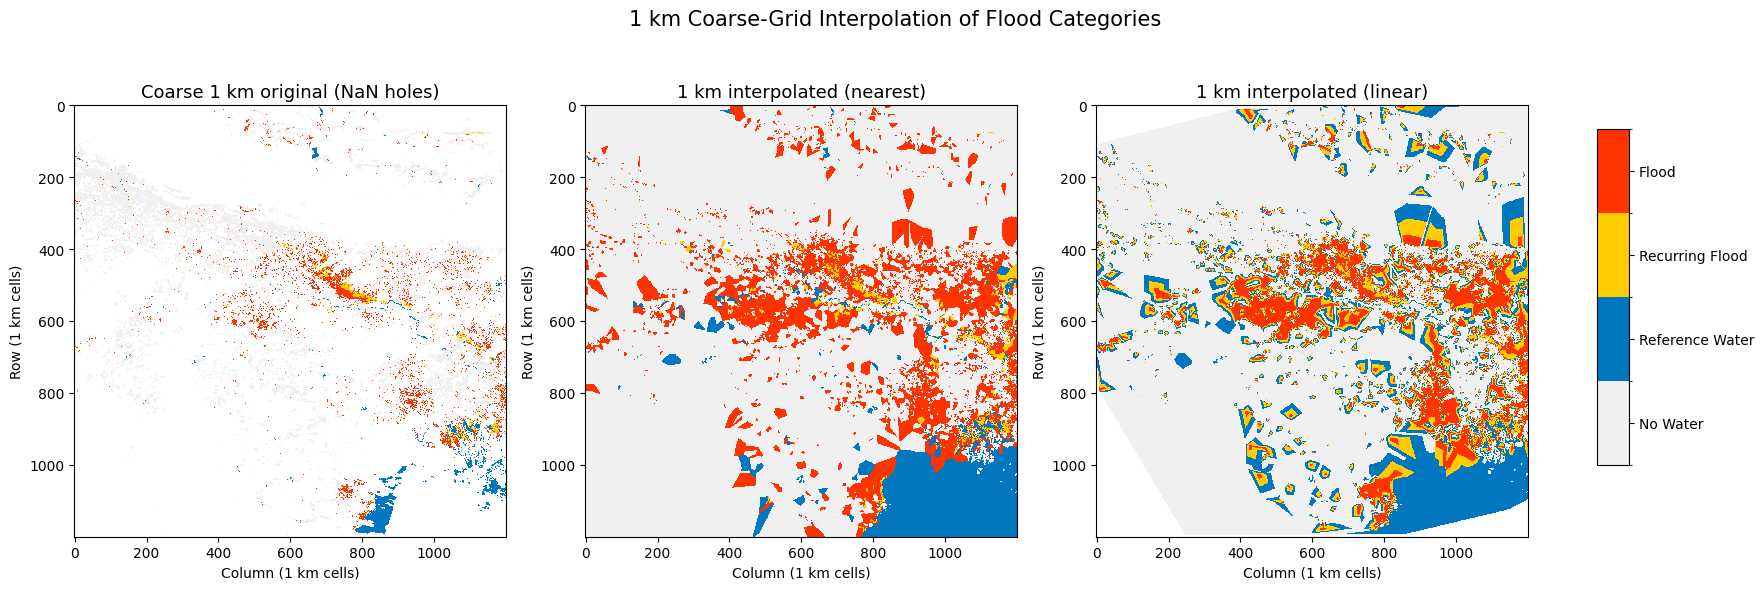

In [21]:
# Cell: Coarse-grid (1 km) interpolation to fill unknown areas
# 250 m -> 1 km = 4x coarsening; use mode for categorical data
from scipy.interpolate import griddata
from scipy.stats import mode as scipy_mode

data = flood_1day.copy()

# Coarsening factor: 1 km / 250 m = 4
factor = 4

# Trim to multiple of factor
h, w = data.shape
h_trim, w_trim = h - h % factor, w - w % factor
data_trim = data[:h_trim, :w_trim]

# Reshape into blocks and compute mode (most common category)
blocks = data_trim.reshape(h_trim // factor, factor, w_trim // factor, factor)
# blocks shape: (nrows, 4, ncols, 4)
coarse = np.full((h_trim // factor, w_trim // factor), np.nan)

for r in range(coarse.shape[0]):
    for c in range(coarse.shape[1]):
        block = blocks[r, :, c, :].ravel()
        known = block[~np.isnan(block)]
        if len(known) > 0:
            # mode returns (most_common_value, count)
            coarse[r, c] = scipy_mode(known, keepdims=False).mode

print(f'Original shape: {data.shape} ({h*w:,} pixels)')
print(f'Coarse shape (1 km): {coarse.shape} ({int(coarse.size):,} pixels)')
print(f'Coarse known: {np.sum(~np.isnan(coarse)):,}')
print(f'Coarse unknown: {np.sum(np.isnan(coarse)):,}')
print()

# Interpolate on coarse grid
rows_c, cols_c = np.indices(coarse.shape)
known_mask_c = ~np.isnan(coarse)
unknown_mask_c = np.isnan(coarse)

known_pts_c = np.column_stack((rows_c[known_mask_c], cols_c[known_mask_c]))
known_vals_c = coarse[known_mask_c]
unknown_pts_c = np.column_stack((rows_c[unknown_mask_c], cols_c[unknown_mask_c]))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = ListedColormap(['#f0f0f0', '#0077be', '#ffcc00', '#ff3300'])
norm = BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

axes[0].imshow(coarse, cmap=cmap, norm=norm, interpolation='none')
axes[0].set_title(f'Coarse 1 km original (NaN holes)', fontsize=13)

for i, method in enumerate(['nearest', 'linear'], start=1):
    interp = griddata(known_pts_c, known_vals_c, unknown_pts_c, method=method)
    reclassed = np.clip(np.round(interp), 0, 3).astype(np.float32)

    filled = coarse.copy()
    filled[unknown_mask_c] = reclassed

    axes[i].imshow(filled, cmap=cmap, norm=norm, interpolation='none')
    axes[i].set_title(f'1 km interpolated ({method})', fontsize=13)

    dist = [int(np.sum(filled[unknown_mask_c] == c)) for c in range(4)]
    print(f'{method}: NaN filled -> No Water:{dist[0]}, Ref Water:{dist[1]}, '
          f'Recur Flood:{dist[2]}, Flood:{dist[3]}')

for ax in axes:
    ax.set_xlabel('Column (1 km cells)')
    ax.set_ylabel('Row (1 km cells)')

plt.suptitle('1 km Coarse-Grid Interpolation of Flood Categories', fontsize=15)
plt.tight_layout(rect=[0, 0, 0.86, 0.95])
cbar_ax = fig.add_axes([0.89, 0.22, 0.018, 0.56])
cbar = fig.colorbar(axes[0].images[0], cax=cbar_ax,
                    ticks=[0.5, 1.5, 2.5, 3.5])
cbar.ax.set_yticklabels(['No Water', 'Reference Water',
                          'Recurring Flood', 'Flood'])
plt.show()